In [2]:
# Step 1: Install required libraries
!pip install scikit-learn pandas matplotlib seaborn


In [3]:
# Step 2: Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Step 3: Upload your dataset from local system
from google.colab import files
uploaded = files.upload()   # upload political_bias.csv manually

Saving Political_Bias_Update.csv to Political_Bias_Update (2).csv


In [5]:
# Step 4: Load dataset
df = pd.read_csv(list(uploaded.keys())[0])
print("✅ Dataset Loaded Successfully!")
print(df.head())

✅ Dataset Loaded Successfully!
                                               Title  \
0  Trumpâ€™s executive order ends federal diversi...   
1  As Trump throws immigration into uncertainty, ...   
2             GOP lawmakers react to Trump's actions   
3       Sweeping Jan. 6 pardons spur mixed reactions   
4  RFK Jr. reports up to $1.2M in credit card deb...   

                                                Link  \
0  https://abcnews.go.com/Politics/video/trumps-e...   
1  https://abcnews.go.com/Politics/trump-throws-i...   
2  https://abcnews.go.com/Politics/video/gop-lawm...   
3  https://abcnews.go.com/Politics/video/sweeping...   
4  https://abcnews.go.com/Politics/rfk-jr-reports...   

                                                Text   Source       Bias  
0                             Error fetching article  abcnews  lean left  
1  As President Donald Trump starts to defend his...  abcnews  lean left  
2                             Error fetching article  abcnews  lean le

In [6]:
# Step 5: Prepare features and labels
# Remove rows where Text is NaN or has placeholder text
df = df.dropna(subset=["Text"])
df = df[~df["Text"].str.contains("Error fetching article", case=False, na=False)]

X = df["Text"]    # text column
y = df["Bias"]    # label column

# Encode string labels to numeric
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("\nLabel Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Label Mapping: {'center': np.int64(0), 'lean left': np.int64(1), 'lean right': np.int64(2), 'left': np.int64(3), 'right': np.int64(4)}


In [7]:
# Step 5: Prepare features and labels
# Remove rows where Text is NaN or has placeholder text
df = df.dropna(subset=["Text"])
df = df[~df["Text"].str.contains("Error fetching article", case=False, na=False)]

X = df["Text"]    # text column
y = df["Bias"]    # label column

# Encode string labels to numeric
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("\nLabel Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Label Mapping: {'center': np.int64(0), 'lean left': np.int64(1), 'lean right': np.int64(2), 'left': np.int64(3), 'right': np.int64(4)}


In [8]:
# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [9]:
# Step 7: Build pipeline with TF-IDF + Logistic Regression
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),        # unigrams + bigrams
        max_features=50000,       # large vocab improves accuracy
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="saga",
        C=2.0
    ))
])

In [11]:
# Step 8: Train model
pipeline.fit(X_train, y_train)
print("\nModel Trained Successfully!")


Model Trained Successfully!



🔹 Multi-class Accuracy: 0.9129057798891528

🔹 Classification Report:
               precision    recall  f1-score   support

      center       0.92      0.89      0.90       131
   lean left       0.83      0.87      0.85       155
  lean right       0.77      0.90      0.83       116
        left       0.94      0.92      0.93       606
       right       0.97      0.94      0.95       255

    accuracy                           0.91      1263
   macro avg       0.89      0.90      0.89      1263
weighted avg       0.92      0.91      0.91      1263

Classification report saved as classification_report.csv


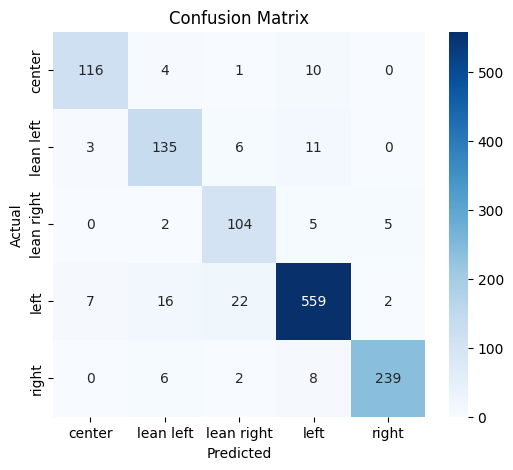


🔹 Test Your Own Political Statement!

Enter a political statement (or type 'exit' to quit):
Investing in renewable energy and public transportation is essential to fight climate change
Predicted Bias: left


In [ ]:
# Step 9: Evaluation
y_pred = pipeline.predict(X_test)

print("\n🔹 Multi-class Accuracy:", accuracy_score(y_test, y_pred))

# Print full classification report
report = classification_report(y_test, y_pred, target_names=le.classes_, digits=2)
print("\n🔹 Classification Report:\n", report)

# Save classification report as table
report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("classification_report.csv")
print("Classification report saved as classification_report.csv")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

# 🔹 Interactive prediction for custom political statements
def predict_bias(text):
    pred = pipeline.predict([text])
    return le.inverse_transform(pred)[0]

print("\n🔹 Test Your Own Political Statement!")
while True:
    user_input = input("\nEnter a political statement (or type 'exit' to quit):\n")
    if user_input.lower() == "exit":
        print("Exiting. Thank you!")
        break
    prediction = predict_bias(user_input)
    print("Predicted Bias:", prediction)

